# 1. Import Featured data

In [2]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

df = pd.read_csv("/Users/kaviraj/Desktop/GUVI/Project3/featured_data.csv")

df

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,day_of_week
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,no_rain,warm,2020-01-01,0,0,0,0,0,0,Wednesday
1,Unknown,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,no_rain,cold,2020-01-01,0,0,0,0,0,0,Wednesday
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,no_rain,warm,2020-01-01,0,0,0,0,0,0,Wednesday
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,moderate,mild,2020-01-01,0,0,0,0,0,1,Wednesday
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,12.0,0,0,...,no_rain,mild,2020-01-01,0,0,0,0,0,0,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109552,psychotherapy,16,M,yes,intellectual,Unknown,afternoon,18.0,0,0,...,no_rain,mild,2021-05-11,0,0,0,0,0,0,Tuesday
109553,speech therapy,9,F,yes,motor,Port Georgestad,morning,18.0,0,0,...,moderate,warm,2021-05-11,0,0,0,0,0,0,Tuesday
109554,psychotherapy,13,F,no,intellectual,Erinton,afternoon,8.0,1,0,...,moderate,mild,2021-05-11,0,0,0,0,0,1,Tuesday
109555,physiotherapy,8,F,no,motor,CAMBORIU,morning,7.0,1,0,...,no_rain,warm,2021-05-11,0,0,0,0,0,0,Tuesday


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109557 entries, 0 to 109556
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    109557 non-null  object 
 1   appointment_time             109557 non-null  int64  
 2   gender                       109557 non-null  object 
 3   no_show                      109557 non-null  object 
 4   disability                   109557 non-null  object 
 5   place                        109557 non-null  object 
 6   appointment_shift            109557 non-null  object 
 7   age                          109557 non-null  float64
 8   under_12_years_old           109557 non-null  int64  
 9   over_60_years_old            109557 non-null  int64  
 10  patient_needs_companion      109557 non-null  int64  
 11  average_temp_day             109557 non-null  float64
 12  average_rain_day             109557 non-null  float64
 13 

In [6]:
# Change dtype of appoitment_date_continuous from object to datetime
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

In [8]:
print(df.columns.tolist())

['specialty', 'appointment_time', 'gender', 'no_show', 'disability', 'place', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity', 'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received', 'day_of_week']


# Exploratory Data Analysis

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

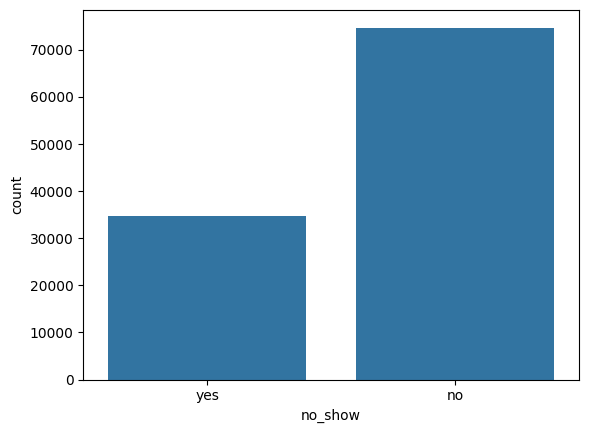

In [11]:
# 1. Target variable analysis

sns.countplot(x='no_show', data=df)
plt.show()

The age distribution is heavily skewed toward younger patients. The median age is 12 years, and 75% of patients are younger than 18 years. This suggests that the rehabilitation center primarily serves children and adolescents.

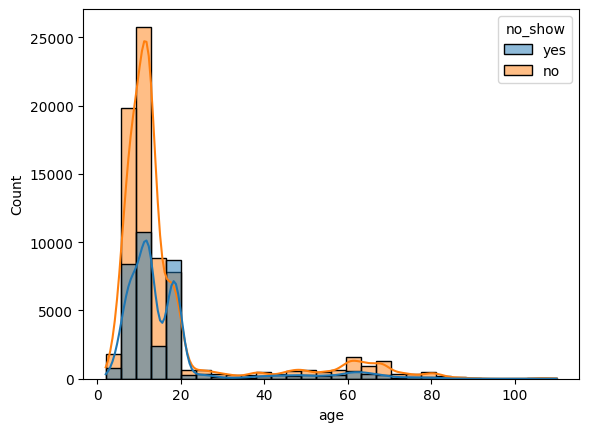

In [19]:
# Age vs No-Show
sns.histplot(
    data=df,
    x='age',
    hue='no_show',
    kde=True,
    bins=30
)
plt.show()

Both attendance groups exhibit very similar age distributions, suggesting that age alone is not a strong predictor of appointment attendance.

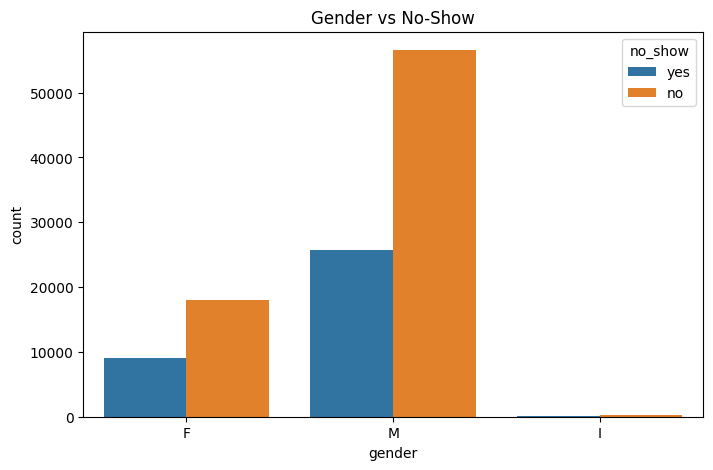

In [35]:
# Gender vs No-Show

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='gender',
    hue='no_show'
)

plt.title('Gender vs No-Show')
plt.show()

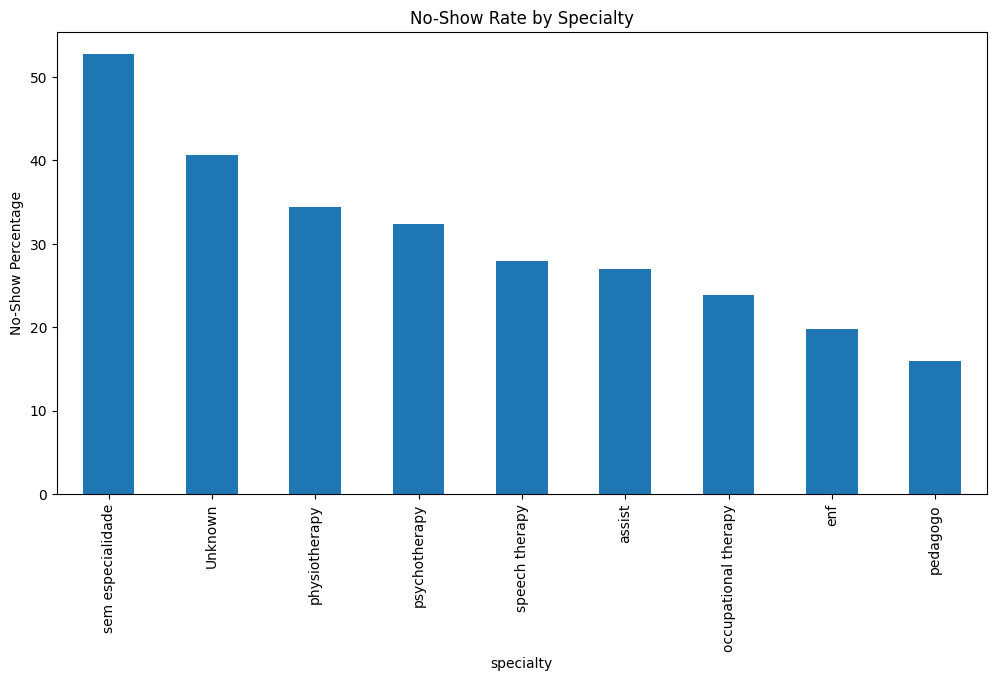

In [36]:
#Specialty vs No-Show

plt.figure(figsize=(12,6))

specialty_rate = pd.crosstab(
    df['specialty'],
    df['no_show'],
    normalize='index'
)*100

specialty_rate['yes'].sort_values(
    ascending=False
).plot(kind='bar')

plt.ylabel('No-Show Percentage')
plt.title('No-Show Rate by Specialty')
plt.show()

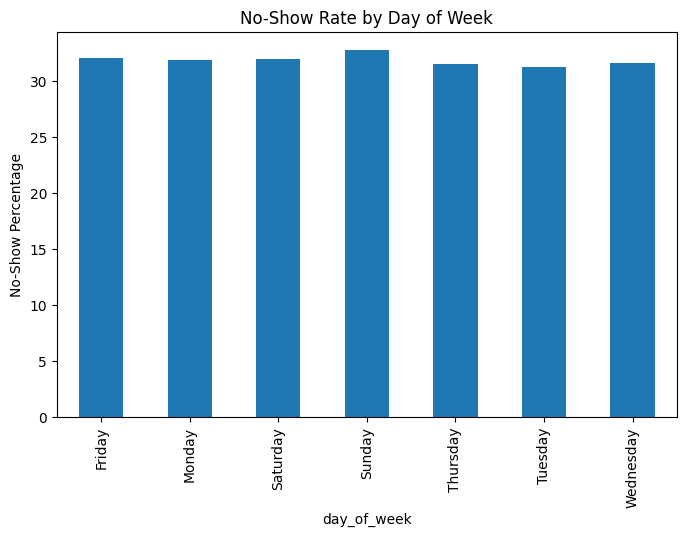

In [22]:
# Day of Week vs No-Show

day_rate = pd.crosstab(
    df['day_of_week'],
    df['no_show'],
    normalize='index'
)*100

day_rate['yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel('No-Show Percentage')
plt.title('No-Show Rate by Day of Week')
plt.show()

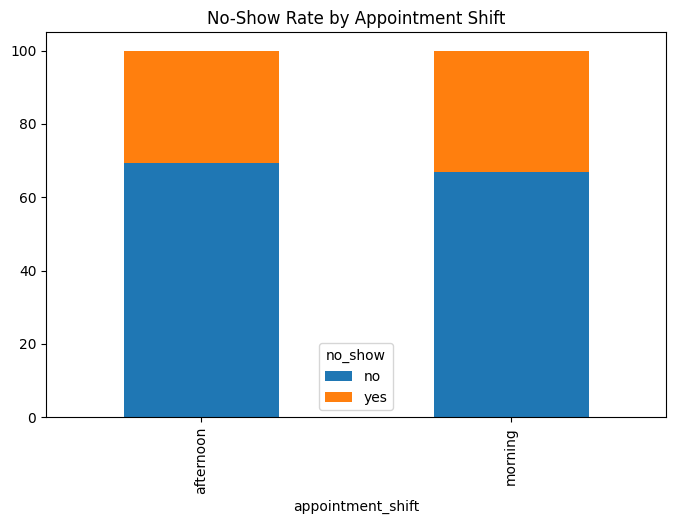

In [43]:
# appointment_shift vs no_show
pd.crosstab(
    df['appointment_shift'],
    df['no_show'],
    normalize='index'
).mul(100).plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
# shift_rate = pd.crosstab(
#     df['appointment_shift'],
#     df['no_show'],
#     normalize='index'
# )*100

# shift_rate['yes'].plot(kind='bar')

plt.title('No-Show Rate by Appointment Shift')
plt.show()

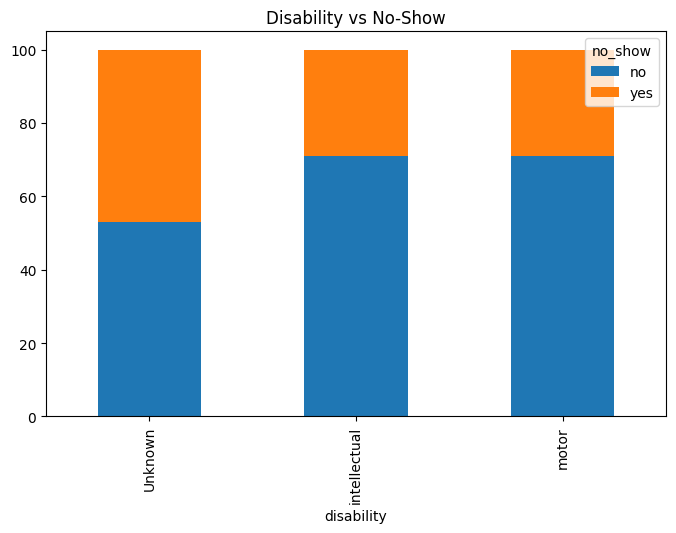

In [24]:
# Disability vs No-Show

pd.crosstab(
    df['disability'],
    df['no_show'],
    normalize='index'
).mul(100).plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Disability vs No-Show')
plt.show()

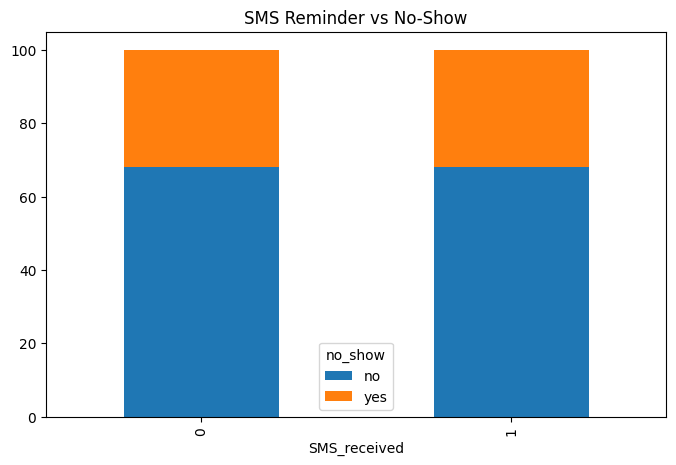

In [44]:
# SMS Reminder vs No-Show

pd.crosstab(
    df['SMS_received'],
    df['no_show'],
    normalize='index'
).mul(100).plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
# sms_rate = pd.crosstab(
#     df['SMS_received'],
#     df['no_show'],
#     normalize='index'
# )*100

# sms_rate['yes'].plot(kind='bar')

plt.title('SMS Reminder vs No-Show')
plt.show()

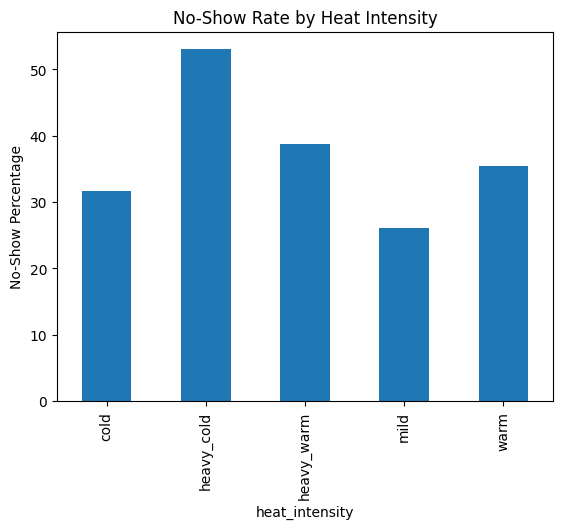

In [39]:
# Heat Intensity vs No_Show

heat_rate = pd.crosstab(
    df['heat_intensity'],
    df['no_show'],
    normalize='index'
)*100

heat_rate['yes'].plot(kind='bar')

plt.ylabel('No-Show Percentage')
plt.title('No-Show Rate by Heat Intensity')
plt.show()

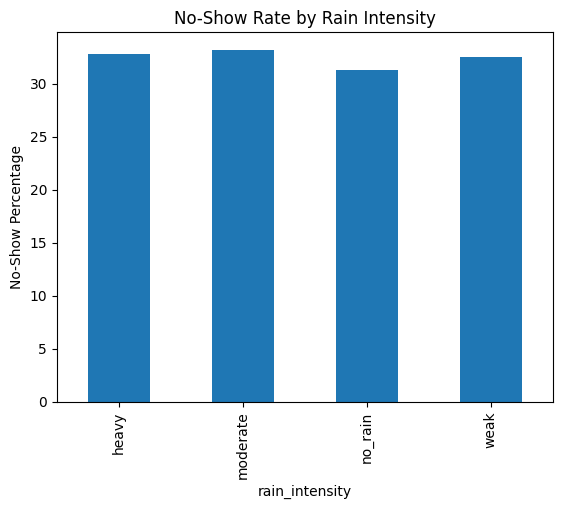

In [28]:
# Rain Intensity vs No_Show

rain_rate = pd.crosstab(
    df['rain_intensity'],
    df['no_show'],
    normalize='index'
)*100

rain_rate['yes'].plot(kind='bar')

plt.ylabel('No-Show Percentage')
plt.title('No-Show Rate by Rain Intensity')
plt.show()

# Correlation Heatmap

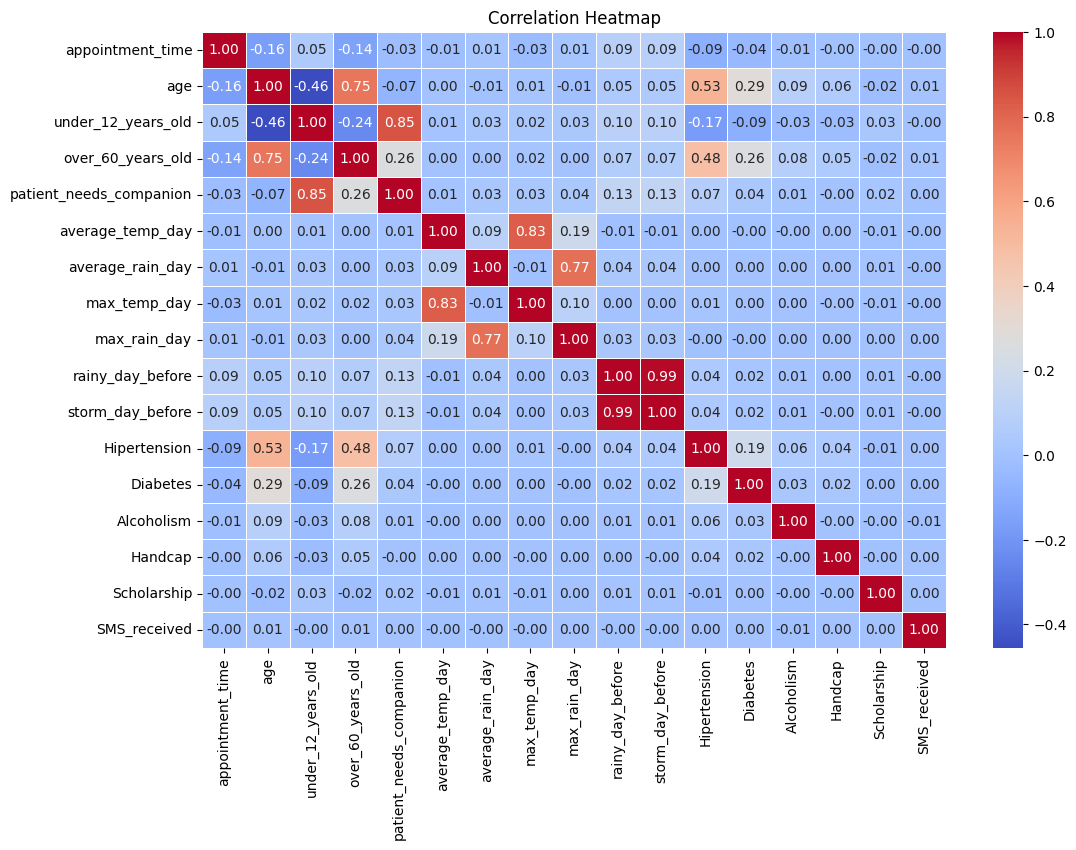

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title("Correlation Heatmap")
plt.show()